In [2]:
import arcpy
import gc  # 導入垃圾回收模組
from arcpy.sa import *

# 1. 環境設定
arcpy.env.overwriteOutput = True
if arcpy.CheckExtension("Spatial") == "Available":
    arcpy.CheckOutExtension("Spatial")

aprx = arcpy.mp.ArcGISProject("CURRENT")
target_gdb = aprx.defaultGeodatabase
active_map = aprx.activeMap

# 輸入資料
gap_raster = "OLP1_2204_GAP2_NC"
dem_diff_raster = "D:\ArcGIS\Morpho_Spatial_Demography\MSD_Hawaii.gdb\OL_P1_2204_diff"

# 產出與暫存 (改用 memory 避免 GDB 鎖定)
temp_table = r"memory\temp_ZonalStats" 
final_poly = fr"{target_gdb}\OLP1_2204_crevice"

try:
    # 2. 空間分析
    print("Step 1: Running SetNull and Region Group...")
    null_gap = SetNull(gap_raster, gap_raster, "Value = 0")
    # RegionGroup 結果通常為 Integer，支持 MEDIAN 計算
    region_grp = Int(RegionGroup(null_gap, "EIGHT", "WITHIN", "NO_LINK"))

    print("Step 2: Calculating Zonal Statistics (including Median)...")
    # "ALL" 在 Pro 中包含 MEAN, MEDIAN, STD, MIN, MAX 等
    ZonalStatisticsAsTable(region_grp, "VALUE", dem_diff_raster, temp_table, "DATA", "ALL")

    # 3. 轉換為向量圖層
    print("Step 3: Converting Raster to Polygon...")
    arcpy.conversion.RasterToPolygon(region_grp, final_poly, "NO_SIMPLIFY", "Value")

    # 4. 讀取統計數據到字典 (加入 MEDIAN)
    # 欄位順序需對應 ZonalStatisticsAsTable 生成的標準欄位名
    stats_dict = {}
    search_fields = ["VALUE", "MEAN", "MAX", "MIN", "STD", "MEDIAN"]
    
    with arcpy.da.SearchCursor(temp_table, search_fields) as cursor:
        for row in cursor:
            # 數據結構: (MEAN, MAX, MIN, VAR, MEDIAN)
            var_val = row[4]**2 if row[4] is not None else 0
            stats_dict[row[0]] = (row[1], row[2], row[3], var_val, row[5])
    
    del cursor # 立即釋放讀取鎖

    # 5. 批量新增欄位
    print("Step 4: Adding attribute fields...")
    field_defs = [
        ["MEAN_VAL", "DOUBLE"], ["MAX_VAL", "DOUBLE"], 
        ["MIN_VAL", "DOUBLE"], ["VAR_VAL", "DOUBLE"],
        ["MEDIAN_VAL", "DOUBLE"], # 新增中位數欄位
        ["AREA_M2", "DOUBLE"], ["PERIM_M", "DOUBLE"]
    ]
    
    existing_fields = [f.name for f in arcpy.ListFields(final_poly)]
    fields_to_add = [f for f in field_defs if f[0] not in existing_fields]
    if fields_to_add:
        arcpy.management.AddFields(final_poly, fields_to_add)

    # 6. 使用 UpdateCursor 填入數據
    print("Step 5: Updating attributes and geometry...")
    update_fields = ["gridcode", "MEAN_VAL", "MAX_VAL", "MIN_VAL", "VAR_VAL", "MEDIAN_VAL", "AREA_M2", "PERIM_M", "SHAPE@AREA", "SHAPE@LENGTH"]
    
    with arcpy.da.UpdateCursor(final_poly, update_fields) as cursor:
        for row in cursor:
            patch_id = row[0]
            if patch_id in stats_dict:
                data = stats_dict[patch_id]
                row[1] = data[0] # MEAN
                row[2] = data[1] # MAX
                row[3] = data[2] # MIN
                row[4] = data[3] # VAR
                row[5] = data[4] # MEDIAN
                row[6] = row[8]  # AREA from SHAPE@AREA
                row[7] = row[9]  # PERIMETER from SHAPE@LENGTH
                cursor.updateRow(row)
    
    del cursor # 立即釋放寫入鎖

    # 7. 更新地圖顯示
    if not any(lyr.name == "Gap_Patches_Final" for lyr in active_map.listLayers()):
        active_map.addDataFromPath(final_poly)

    print("--- Process Completed Successfully ---")

except Exception as e:
    print(f"❌ Error occurred: {e}")

finally:
    # 8. 深度清理鎖定 (關鍵優化區)
    print("Finalizing and releasing locks...")
    
    # 刪除所有可能的引用物件
    variables_to_del = ['cursor', 'row', 'stats_dict', 'null_gap', 'region_grp']
    for var in variables_to_del:
        if var in locals():
            del locals()[var]
    
    # 清理記憶體暫存表
    if arcpy.Exists(temp_table):
        arcpy.management.Delete(temp_table)
    
    # 強制執行垃圾回收
    gc.collect()
    
    # 清除工作空間緩存
    arcpy.ClearWorkspaceCache_management()
    
    # 歸還擴充模組
    arcpy.CheckInExtension("Spatial")
    
    print("✅ All intermediate data cleared and locks released.")

<>:16: SyntaxWarning: invalid escape sequence '\A'
C:/Users/keelu/AppData/Local/Temp/ArcGISProTemp2192/xpython_2192/917276183.py:16: SyntaxWarning: invalid escape sequence '\A'
  dem_diff_raster = "D:\ArcGIS\Morpho_Spatial_Demography\MSD_Hawaii.gdb\OL_P1_2204_diff"


Step 1: Running SetNull and Region Group...
Step 2: Calculating Zonal Statistics (including Median)...
Step 3: Converting Raster to Polygon...
Step 4: Adding attribute fields...
Step 5: Updating attributes and geometry...
--- Process Completed Successfully ---
Finalizing and releasing locks...
✅ All intermediate data cleared and locks released.


Classifying data based on MEAN_VAL...

Class    | Count      | Count %    | Total Area      | Area %    
--------------------------------------------------------------------------------
1        | 2377       |    10.30% |            0.31 |     3.81%
2        | 14864      |    64.44% |            4.59 |    57.00%
3        | 4352       |    18.87% |            2.49 |    30.92%
4        | 1170       |     5.07% |            0.58 |     7.18%
5        | 305        |     1.32% |            0.09 |     1.10%
--------------------------------------------------------------------------------
Total    | 23068      | 100.00%    |            8.06 | 100.00%

Suggested intervals for 5 Equal-Count classes (Quantiles):
Class 1: <= 0.004379
Class 2: 0.004379 - 0.005224
Class 3: 0.005224 - 0.006513
Class 4: 0.006513 - 0.008768
Class 5: > 0.008768



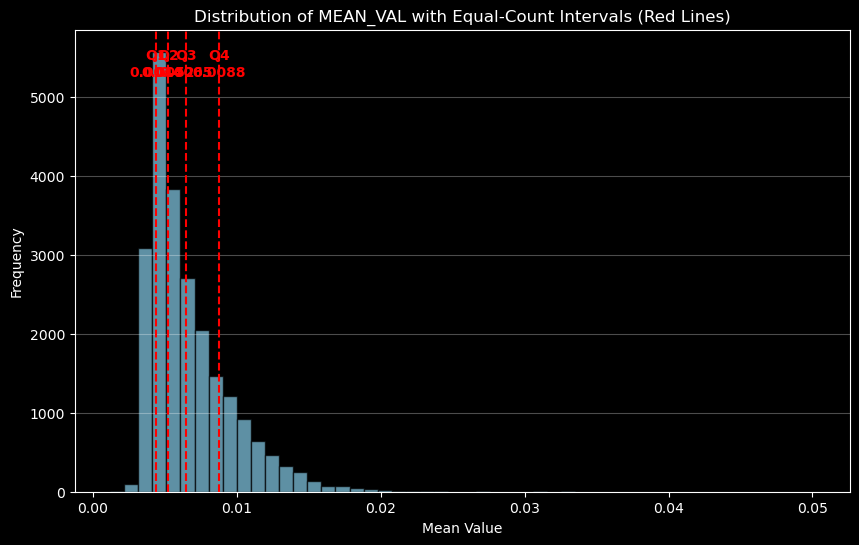

In [3]:
import arcpy
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
fc = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Hawaii.gdb\k1a_Gap_Patches"
field_name = "crevice_class"
value_field = "MEAN_VAL"
area_field = "Shape_Area"

# 1. Add Field if not exists
fields = [f.name for f in arcpy.ListFields(fc)]
if field_name not in fields:
    print(f"Adding field: {field_name}...")
    arcpy.management.AddField(fc, field_name, "SHORT")

# 2. Classification Logic (Manual Breaks)
print("Classifying data based on MEAN_VAL...")
all_values = [] # For distribution analysis
with arcpy.da.UpdateCursor(fc, [value_field, field_name, area_field]) as cursor:
    for row in cursor:
        val = row[0]
        if val is not None:
            all_values.append(val) # Collect data for plotting
            
            # Assignment based on your specific thresholds
            if val <= 0.004: row[1] = 1
            elif val <= 0.008: row[1] = 2
            elif val <= 0.012: row[1] = 3
            elif val <= 0.016: row[1] = 4
            else: row[1] = 5
            cursor.updateRow(row)

# 3. Statistics Calculation
stats_dict = {}
total_count = 0
total_area_all = 0

with arcpy.da.SearchCursor(fc, [field_name, area_field]) as cursor:
    for row in cursor:
        cls, area = row
        if cls not in stats_dict: stats_dict[cls] = [0, 0.0]
        stats_dict[cls][0] += 1
        stats_dict[cls][1] += area
        total_count += 1
        total_area_all += area

# 4. Print Results in English
print("\n" + "="*80)
print(f"{'Class':<8} | {'Count':<10} | {'Count %':<10} | {'Total Area':<15} | {'Area %':<10}")
print("-" * 80)

for cls in sorted(stats_dict.keys()):
    cnt, area = stats_dict[cls]
    cnt_pct = (cnt / total_count) * 100
    area_pct = (area / total_area_all) * 100
    print(f"{cls:<8} | {cnt:<10} | {cnt_pct:>8.2f}% | {area:>15.2f} | {area_pct:>8.2f}%")

print("-" * 80)
print(f"Total    | {total_count:<10} | 100.00%    | {total_area_all:>15.2f} | 100.00%")
print("="*80 + "\n")

# 5. Calculate Quantiles (Equal-Count Intervals)
# These values would split the data into 5 groups with equal number of features
quantiles = np.percentile(all_values, [20, 40, 60, 80])
print("Suggested intervals for 5 Equal-Count classes (Quantiles):")
print(f"Class 1: <= {quantiles[0]:.6f}")
print(f"Class 2: {quantiles[0]:.6f} - {quantiles[1]:.6f}")
print(f"Class 3: {quantiles[1]:.6f} - {quantiles[2]:.6f}")
print(f"Class 4: {quantiles[2]:.6f} - {quantiles[3]:.6f}")
print(f"Class 5: > {quantiles[3]:.6f}\n")

# 6. Data Visualization
plt.figure(figsize=(10, 6))
plt.hist(all_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Mark the Quantile lines
for q in quantiles:
    plt.axvline(q, color='red', linestyle='--', linewidth=1.5)

plt.title(f"Distribution of {value_field} with Equal-Count Intervals (Red Lines)")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)

# Add text labels for quantiles
for i, q in enumerate(quantiles):
    plt.text(q, plt.ylim()[1]*0.9, f'Q{i+1}\n{q:.4f}', color='red', ha='center', fontweight='bold')

plt.show()